# 🚲 Dublin Bikes 可用性预测模型

## 项目目标
基于历史单车数据和天气数据，训练一个机器学习模型，  
预测某个站点在特定时间的**可用单车数量**。

## 数据集
- 文件名：`final_merged_data.csv`
- 内容：合并了单车站点历史数据 + 天气数据

## Notebook 结构
1. 环境准备 & 数据加载
2. 数据探索（EDA）
3. 数据清洗 & 预处理
4. 特征工程
5. 模型训练 & 对比
6. 模型评估
7. 保存最优模型

In [1]:
# 数据处理
import pandas as pd
import numpy as np

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# 机器学习
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 模型保存
import pickle
import joblib

# 其他
import warnings
warnings.filterwarnings('ignore')

# 设置可视化风格
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置pandas显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ 所有库导入成功")

✅ 所有库导入成功


## 1. 数据加载

读取 `final_merged_data.csv`，并进行初步查看：
- 数据的行列数
- 前几行预览
- 列名和数据类型
- 基本统计信息

In [2]:
# 加载数据
df = pd.read_csv('final_merged_data.csv')

# 基本信息
print(f"📊 数据集大小: {df.shape[0]} 行 x {df.shape[1]} 列")
print(f"\n📋 列名列表:")
print(df.columns.tolist())
print(f"\n🔍 数据类型:")
print(df.dtypes)

📊 数据集大小: 298946 行 x 78 列

📋 列名列表:
['last_reported', 'station_id', 'num_bikes_available', 'num_docks_available', 'is_installed', 'is_renting', 'is_returning', 'name', 'address', 'lat', 'lon', 'capacity', 'stno', 'year', 'month', 'day', 'hour', 'minute', 'max_air_temp_quality_indicator', 'max_air_temperature_celsius', 'min_air_temp_quality_indicator', 'min_air_temperature_celsius', 'air_temp_std_quality_indicator', 'air_temperature_std_deviation', 'max_grass_temp_quality_indicator', 'max_grass_temperature_celsius', 'min_grass_temp_quality_indicator', 'min_grass_temperature_celsius', 'grass_temp_std_quality_indicator', 'grass_temperature_std_deviation', 'max_soil_temp_5cm_quality_indicator', 'max_soil_temperature_5cm_celsius', 'min_soil_temp_5cm_quality_indicator', 'min_soil_temperature_5cm_celsius', 'soil_temp_std_5cm_quality_indicator', 'soil_temperature_std_deviation_5cm', 'max_soil_temp_10cm_quality_indicator', 'max_soil_temperature_10cm_celsius', 'min_soil_temp_10cm_quality_indicator

## 2. 数据初步探索（EDA）

先查看数据的基本情况：
- 缺失值分布
- 目标变量分布
- 预览前几行

In [3]:
# 预览前5行
print("📋 前5行数据预览：")
df.head()

📋 前5行数据预览：


,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,lon,capacity,stno,year,month,day,hour,minute,max_air_temp_quality_indicator,max_air_temperature_celsius,min_air_temp_quality_indicator,min_air_temperature_celsius,air_temp_std_quality_indicator,air_temperature_std_deviation,max_grass_temp_quality_indicator,max_grass_temperature_celsius,min_grass_temp_quality_indicator,min_grass_temperature_celsius,grass_temp_std_quality_indicator,grass_temperature_std_deviation,max_soil_temp_5cm_quality_indicator,max_soil_temperature_5cm_celsius,min_soil_temp_5cm_quality_indicator,min_soil_temperature_5cm_celsius,soil_temp_std_5cm_quality_indicator,soil_temperature_std_deviation_5cm,max_soil_temp_10cm_quality_indicator,max_soil_temperature_10cm_celsius,min_soil_temp_10cm_quality_indicator,min_soil_temperature_10cm_celsius,soil_temp_std_10cm_quality_indicator,soil_temperature_std_deviation_10cm,max_soil_temp_20cm_quality_indicator,max_soil_temperature_20cm_celsius,min_soil_temp_20cm_quality_indicator,min_soil_temperature_20cm_celsius,soil_temp_std_20cm_quality_indicator,soil_temperature_std_deviation_20cm,max_earth_temp_30cm_quality_indicator,max_earth_temperature_30cm_celsius,min_earth_temp_30cm_quality_indicator,min_earth_temperature_30cm_celsius,earth_temp_std_30cm_quality_indicator,earth_temperature_std_deviation_30cm,max_earth_temp_50cm_quality_indicator,max_earth_temperature_50cm_celsius,min_earth_temp_50cm_quality_indicator,min_earth_temperature_50cm_celsius,earth_temp_std_50cm_quality_indicator,earth_temperature_std_deviation_50cm,max_earth_temp_100cm_quality_indicator,max_earth_temperature_100cm_celsius,min_earth_temp_100cm_quality_indicator,min_earth_temperature_100cm_celsius,earth_temp_std_100cm_quality_indicator,earth_temperature_std_deviation_100cm,max_humidity_quality_indicator,max_relative_humidity_percent,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344,-6.267,16,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347,-6.292,25,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353,-6.249,29,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
3,2024-12-01 00:10:00,11,1,29,True,True,True,EARLSFORT TERRACE,Earlsfort Terrace,53.334,-6.259,30,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
4,2024-12-01 00:10:00,114,4,36,True,True,True,WILTON TERRACE (PARK),Wilton Terrace (Park),53.334,-6.248,40,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0

In [4]:
# 缺失值统计
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '缺失数量': missing,
    '缺失比例(%)': missing_pct
}).query('缺失数量 > 0').sort_values('缺失比例(%)', ascending=False)

print(f"⚠️  共有 {len(missing_df)} 列存在缺失值：\n")
print(missing_df)

⚠️  共有 0 列存在缺失值：

Empty DataFrame
Columns: [缺失数量, 缺失比例(%)]
Index: []


📊 目标变量 num_bikes_available 统计：
count   298946.000
mean        12.205
std          9.762
min          0.000
25%          4.000
50%         11.000
75%         19.000
max         40.000
Name: num_bikes_available, dtype: float64


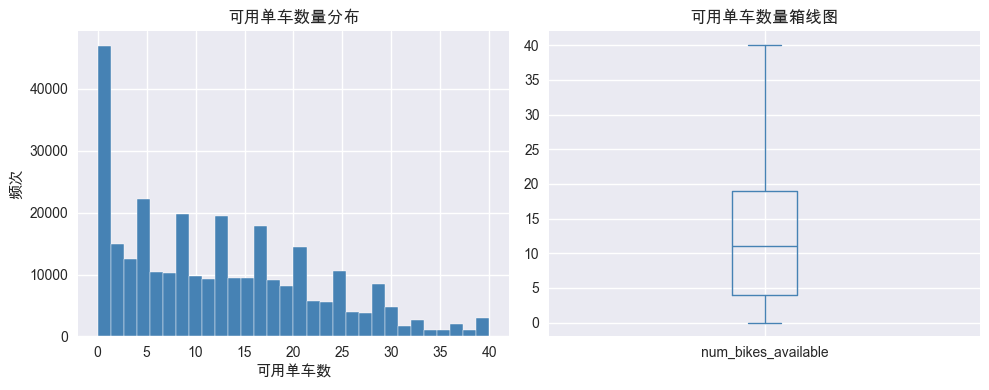

In [5]:
# 目标变量分布
print("📊 目标变量 num_bikes_available 统计：")
print(df['num_bikes_available'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['num_bikes_available'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('可用单车数量分布')
plt.xlabel('可用单车数')
plt.ylabel('频次')

plt.subplot(1, 2, 2)
df['num_bikes_available'].plot(kind='box', color='steelblue')
plt.title('可用单车数量箱线图')

plt.tight_layout()
plt.show()

## 3. 特征选择

根据数据列分析，保留以下有意义的特征：

**时间特征：** `hour`, `month`, `day`, `year`

**站点特征：** `station_id`, `capacity`, `lat`, `lon`

**天气特征：**
- 气温：`max_air_temperature_celsius`, `min_air_temperature_celsius`
- 湿度：`max_relative_humidity_percent`, `min_relative_humidity_percent`
- 气压：`max_barometric_pressure_hpa`, `min_barometric_pressure_hpa`

**删除原因：**
- 所有 `quality_indicator` 列 → 质量标记，不是实际数值
- 所有 `std_deviation` 列 → 信息冗余
- 土壤/草地温度 → 与单车使用相关性低
- `name`, `address`, `last_reported` → 文字列，不参与建模
- `is_installed`, `is_renting`, `is_returning` → 几乎全为True，无区分度

**目标变量：** `num_bikes_available`

In [6]:
# 选择需要的列
selected_columns = [
    # 时间特征
    'hour', 'month', 'day', 'year',
    
    # 站点特征
    'station_id', 'capacity', 'lat', 'lon',
    
    # 天气特征
    'max_air_temperature_celsius', 'min_air_temperature_celsius',
    'max_relative_humidity_percent', 'min_relative_humidity_percent',
    'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa',
    
    # 目标变量
    'num_bikes_available'
]

# 创建新的DataFrame
df_model = df[selected_columns].copy()

print(f"✅ 特征选择完成")
print(f"📊 新数据集大小: {df_model.shape[0]} 行 x {df_model.shape[1]} 列")
print(f"\n📋 各列数据类型:")
print(df_model.dtypes)
print(f"\n📋 前5行预览:")
df_model.head()

✅ 特征选择完成
📊 新数据集大小: 298946 行 x 15 列

📋 各列数据类型:
hour                               int64
month                              int64
day                                int64
year                               int64
station_id                         int64
capacity                           int64
lat                              float64
lon                              float64
max_air_temperature_celsius      float64
min_air_temperature_celsius      float64
max_relative_humidity_percent    float64
min_relative_humidity_percent    float64
max_barometric_pressure_hpa      float64
min_barometric_pressure_hpa      float64
num_bikes_available                int64
dtype: object

📋 前5行预览:


,hour,month,day,year,station_id,capacity,lat,lon,max_air_temperature_celsius,min_air_temperature_celsius,max_relative_humidity_percent,min_relative_humidity_percent,max_barometric_pressure_hpa,min_barometric_pressure_hpa,num_bikes_available
0,0,12,1,2024,10,16,53.344,-6.267,14.010,13.900,84.300,83.200,1002.560,1002.260,15
1,0,12,1,2024,100,25,53.347,-6.292,14.010,13.900,84.300,83.200,1002.560,1002.260,17
2,0,12,1,2024,109,29,53.353,-6.249,14.010,13.900,84.300,83.200,1002.560,1002.260,20
3,0,12,1,2024,11,30,53.334,-6.259,14.010,13.900,84.300,83.200,1002.560,1002.260,1
4,0,12,1,2024,114,40,53.334,-6.248,14.010,13.900,84.300,83.200,1002.560,1002.260,4


## 4. 特征工程

在现有特征基础上，新增以下衍生特征：

- `day_of_week`：星期几（0=周一，6=周日），捕捉工作日/周末规律
- `is_weekend`：是否为周末（0或1），更直接的周末标记
- `avg_temperature`：最高最低气温的平均值，作为代表性气温
- `avg_humidity`：最高最低湿度的平均值
- `avg_pressure`：最高最低气压的平均值

In [7]:
# 新增衍生特征
# 需要先将last_reported转换为datetime来获取星期几
df_model['day_of_week'] = pd.to_datetime(df[['year', 'month', 'day']]).dt.dayofweek

# 是否为周末
df_model['is_weekend'] = df_model['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 平均气温
df_model['avg_temperature'] = (df_model['max_air_temperature_celsius'] + df_model['min_air_temperature_celsius']) / 2

# 平均湿度
df_model['avg_humidity'] = (df_model['max_relative_humidity_percent'] + df_model['min_relative_humidity_percent']) / 2

# 平均气压
df_model['avg_pressure'] = (df_model['max_barometric_pressure_hpa'] + df_model['min_barometric_pressure_hpa']) / 2

print(f"✅ 特征工程完成")
print(f"📊 新数据集大小: {df_model.shape[0]} 行 x {df_model.shape[1]} 列")
print(f"\n新增特征统计：")
print(df_model[['day_of_week', 'is_weekend', 'avg_temperature', 'avg_humidity', 'avg_pressure']].describe())

✅ 特征工程完成
📊 新数据集大小: 298946 行 x 20 列

新增特征统计：
       day_of_week  is_weekend  avg_temperature  avg_humidity  avg_pressure
count   298946.000  298946.000       298946.000    298946.000    298946.000
mean         2.923       0.282            7.786        84.285      1014.773
std          2.061       0.450            3.129         8.005        11.859
min          0.000       0.000           -3.484        55.070       975.035
25%          1.000       0.000            5.676        79.770      1005.915
50%          3.000       0.000            7.872        85.350      1017.125
75%          5.000       1.000           10.125        89.600      1022.615
max          6.000       1.000           14.630        98.850      1035.775


## 5. 相关性分析

查看各特征与目标变量 `num_bikes_available` 的相关性，
帮助我们确认哪些特征对预测最有帮助。

📊 各特征与 num_bikes_available 的相关性：
capacity                         0.205
lon                              0.125
day_of_week                      0.010
min_relative_humidity_percent    0.009
avg_humidity                     0.009
max_relative_humidity_percent    0.009
is_weekend                       0.007
day                              0.004
max_air_temperature_celsius      0.002
avg_temperature                  0.002
min_air_temperature_celsius      0.002
station_id                      -0.001
max_barometric_pressure_hpa     -0.002
avg_pressure                    -0.002
min_barometric_pressure_hpa     -0.002
hour                            -0.005
lat                             -0.138
month                              NaN
year                               NaN
Name: num_bikes_available, dtype: float64


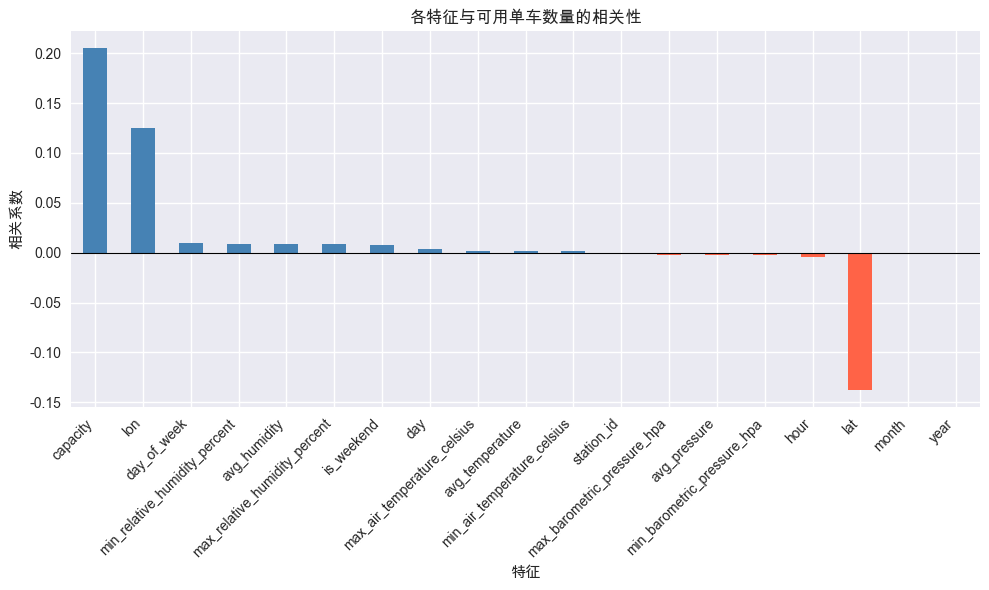

In [8]:
# 计算相关性矩阵
corr_matrix = df_model.corr()

# 提取与目标变量的相关性并排序
target_corr = corr_matrix['num_bikes_available'].drop('num_bikes_available').sort_values(ascending=False)

print("📊 各特征与 num_bikes_available 的相关性：")
print(target_corr)

# 可视化
plt.figure(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'tomato' for x in target_corr.values]
target_corr.plot(kind='bar', color=colors)
plt.title('各特征与可用单车数量的相关性')
plt.xlabel('特征')
plt.ylabel('相关系数')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [9]:
# 检查 month 和 year 的唯一值
print("month 唯一值：", df_model['month'].unique())
print("year 唯一值：", df_model['year'].unique())

# 这两列如果只有一个值，方差为0，相关性无法计算
print("\nmonth 方差：", df_model['month'].var())
print("year 方差：", df_model['year'].var())

month 唯一值： [12]
year 唯一值： [2024]

month 方差： 0.0
year 方差： 0.0


In [10]:
# 删除方差为0的列（对预测无帮助）
df_model = df_model.drop(columns=['month', 'year'])

print(f"✅ 已删除 month 和 year 列")
print(f"📊 当前数据集大小: {df_model.shape[0]} 行 x {df_model.shape[1]} 列")
print(f"\n📋 当前所有特征：")
print(df_model.columns.tolist())

✅ 已删除 month 和 year 列
📊 当前数据集大小: 298946 行 x 18 列

📋 当前所有特征：
['hour', 'day', 'station_id', 'capacity', 'lat', 'lon', 'max_air_temperature_celsius', 'min_air_temperature_celsius', 'max_relative_humidity_percent', 'min_relative_humidity_percent', 'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa', 'num_bikes_available', 'day_of_week', 'is_weekend', 'avg_temperature', 'avg_humidity', 'avg_pressure']


## 6. 定义最终特征集

根据相关性分析结果，定义最终用于训练的特征：

**最终特征列表：**
- 站点特征：`station_id`, `capacity`, `lat`, `lon`
- 时间特征：`hour`, `day`, `day_of_week`, `is_weekend`
- 天气特征：`avg_temperature`, `avg_humidity`, `avg_pressure`

**说明：**
- 删除原始天气列（`max/min`），保留平均值版本，减少冗余
- 保留所有站点和时间特征
- 目标变量：`num_bikes_available`

In [11]:
# 定义特征和目标变量
features = [
    'station_id', 'capacity', 'lat', 'lon',
    'hour', 'day', 'day_of_week', 'is_weekend',
    'avg_temperature', 'avg_humidity', 'avg_pressure'
]

target = 'num_bikes_available'

X = df_model[features]
y = df_model[target]

# 划分训练集和测试集（70% 训练，30% 测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✅ 数据集划分完成")
print(f"📊 训练集大小: {X_train.shape[0]} 行")
print(f"📊 测试集大小: {X_test.shape[0]} 行")
print(f"📋 特征数量: {X_train.shape[1]} 个")
print(f"\n特征列表: {features}")

✅ 数据集划分完成
📊 训练集大小: 209262 行
📊 测试集大小: 89684 行
📋 特征数量: 11 个

特征列表: ['station_id', 'capacity', 'lat', 'lon', 'hour', 'day', 'day_of_week', 'is_weekend', 'avg_temperature', 'avg_humidity', 'avg_pressure']


## 7. 模型训练与对比

我们将训练以下4个回归模型并对比性能：

| 模型 | 说明 |
|------|------|
| Linear Regression | 线性回归，作为基准模型 |
| Decision Tree | 决策树，可捕捉非线性关系 |
| Random Forest | 随机森林，集成学习，通常效果更好 |
| Gradient Boosting | 梯度提升，通常是最强的传统ML模型 |

**评估指标：**
- `MAE`（平均绝对误差）：越小越好
- `RMSE`（均方根误差）：越小越好  
- `R²`（决定系数）：越接近1越好

In [12]:
from sklearn.metrics import mean_squared_error

# 定义模型
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 训练并评估每个模型
results = []

for name, model in models.items():
    print(f"⏳ 正在训练 {name}...")
    
    # 训练
    model.fit(X_train, y_train)
    
    # 预测
    y_pred = model.predict(X_test)
    
    # 评估
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        '模型': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    })
    
    print(f"   ✅ MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

# 汇总结果
results_df = pd.DataFrame(results).set_index('模型')
print(f"\n📊 模型对比汇总：")
print(results_df)

⏳ 正在训练 Linear Regression...
   ✅ MAE: 7.8289 | RMSE: 9.3659 | R²: 0.0746
⏳ 正在训练 Decision Tree...
   ✅ MAE: 0.9700 | RMSE: 2.3755 | R²: 0.9405
⏳ 正在训练 Random Forest...
   ✅ MAE: 0.8986 | RMSE: 1.6418 | R²: 0.9716
⏳ 正在训练 Gradient Boosting...
   ✅ MAE: 6.1196 | RMSE: 7.5375 | R²: 0.4007

📊 模型对比汇总：
                    MAE  RMSE    R²
模型                                 
Linear Regression 7.829 9.366 0.075
Decision Tree     0.970 2.376 0.941
Random Forest     0.899 1.642 0.972
Gradient Boosting 6.120 7.537 0.401


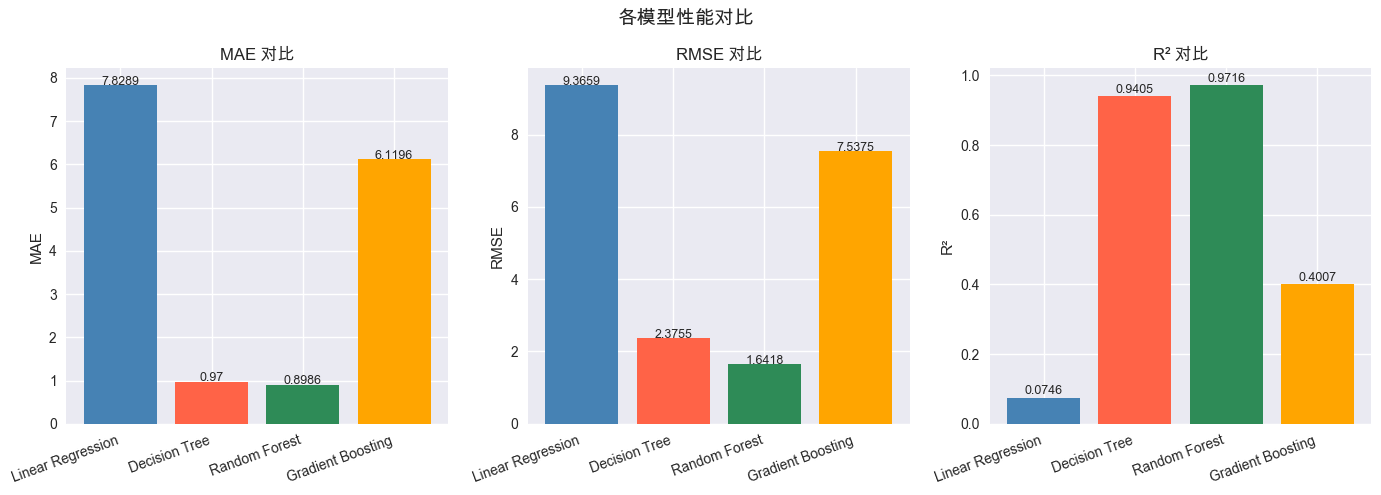

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R²']
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric], color=colors)
    axes[i].set_title(f'{metric} 对比')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df.index, rotation=20, ha='right')
    
    # 在柱子上显示数值
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, str(v), ha='center', fontsize=9)

plt.suptitle('各模型性能对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 特征重要性分析

使用最优模型 Random Forest 查看各特征的重要性，
了解哪些特征对预测贡献最大。

📊 特征重要性排名：
lat               0.199
lon               0.136
day               0.130
hour              0.108
avg_pressure      0.097
station_id        0.090
capacity          0.067
day_of_week       0.061
avg_temperature   0.055
avg_humidity      0.044
is_weekend        0.013
dtype: float64


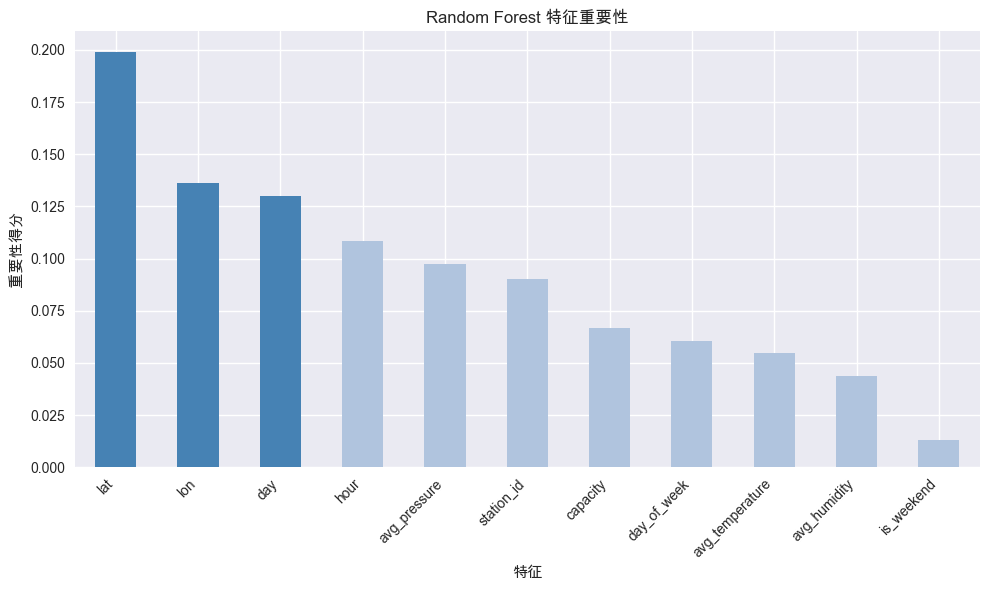

In [14]:
# 获取Random Forest的特征重要性
best_model = models['Random Forest']
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("📊 特征重要性排名：")
print(feature_importance)

# 可视化
plt.figure(figsize=(10, 6))
colors = ['steelblue' if i < 3 else 'lightsteelblue' for i in range(len(feature_importance))]
feature_importance.plot(kind='bar', color=colors)
plt.title('Random Forest 特征重要性')
plt.xlabel('特征')
plt.ylabel('重要性得分')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. 保存最优模型

将 Random Forest 模型保存为 `.pkl` 文件，
供后续 Flask 应用加载使用。

同时保存特征列表，确保预测时使用相同的特征顺序。

In [15]:
# 保存 Random Forest 模型
model_filename = 'bike_availability_model.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

# 同时保存特征列表
features_filename = 'model_features.pkl'
with open(features_filename, 'wb') as f:
    pickle.dump(features, f)

print(f"✅ 模型已保存至: {model_filename}")
print(f"✅ 特征列表已保存至: {features_filename}")

# 验证：重新加载模型并测试
with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)

# 用测试集的第一行验证
test_sample = X_test.iloc[[0]]
prediction = loaded_model.predict(test_sample)
actual = y_test.iloc[0]

print(f"\n🔍 模型验证：")
print(f"   输入特征: {test_sample.values[0]}")
print(f"   预测值: {prediction[0]:.2f} 辆")
print(f"   实际值: {actual} 辆")
print(f"   误差: {abs(prediction[0] - actual):.2f} 辆")

✅ 模型已保存至: bike_availability_model.pkl
✅ 特征列表已保存至: model_features.pkl

🔍 模型验证：
   输入特征: [ 97.        40.        53.342113  -6.310015  17.        31.
   1.         0.         9.67      87.4      998.525   ]
   预测值: 31.41 辆
   实际值: 31 辆
   误差: 0.41 辆


## 10. 总结

### 模型训练结果

| 模型 | MAE | RMSE | R² |
|------|-----|------|----|
| Linear Regression | 7.829 | 9.366 | 0.075 |
| Decision Tree | 0.970 | 2.376 | 0.941 |
| **Random Forest** | **0.899** | **1.642** | **0.972** |
| Gradient Boosting | 6.120 | 7.537 | 0.401 |

### 最优模型：Random Forest
- 平均预测误差不到 1 辆单车
- R² 达到 0.972，解释了97%的数据方差

### 最重要的特征
1. `lat` / `lon` — 地理位置
2. `day` / `hour` — 时间
3. `avg_pressure` — 气压
4. `station_id` / `capacity` — 站点信息

### 下一步
- 将 `bike_availability_model.pkl` 部署到 Flask 应用
- 通过 OpenWeather API 获取实时天气数据进行预测